# CITE-seq ADT batch correction benchmark

This notebook evaluates ADT batch correction on the public scvi-tools PBMC10k/PBMC5k CITE-seq tutorial data. ADT counts are handled as a marker matrix: raw counts are kept in `layers["counts"]`, and `adata.X` stores `log1p(counts)` for cyCombinePy and expression-level comparisons.

The data source is `CITE-seq_pbmc_combined_preprocessed.h5mu` from the scvi-tools totalVI tutorial. It contains `rna_subset` and `prot` modalities with a shared `batch` annotation for the two 10x PBMC batches. The Seurat WNN PBMC CITE-seq vignette is useful background, but this notebook uses the Python-native MuData file so the objects stay in AnnData and MuData form.

```{note}
Documentation builds render the stored outputs in this notebook, but they do not re-execute it. Running all cells downloads a public file of about 425 MB and trains a small totalVI model. Use `pip install "cycombinepy[benchmark]"` before executing it interactively.
```


## Setup

The benchmark extra installs the optional packages used here:

```bash
pip install "cycombinepy[benchmark]"
```

Set `CYCOMBINEPY_DATA_DIR` to reuse a shared cache location. Set `CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH` to lower the per-batch subset size, and set `TOTALVI_MAX_EPOCHS=2` for a quick smoke test.


In [1]:
from __future__ import annotations

import os
from io import BytesIO
from pathlib import Path
from urllib.request import Request, urlopen

RUNTIME_CACHE = Path(os.environ.get('CYCOMBINEPY_RUNTIME_CACHE', '/tmp/cycombinepy-citeseq-cache')).expanduser()
for name, env_var in {
    'matplotlib': 'MPLCONFIGDIR',
    'xdg': 'XDG_CACHE_HOME',
    'numba': 'NUMBA_CACHE_DIR',
}.items():
    path = RUNTIME_CACHE / name
    path.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_var, str(path))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import Image, display
from scipy import sparse

import cycombinepy
from cycombinepy.correct import CORRECTED_LAYER

SEED = 0
rng = np.random.default_rng(SEED)
sc.set_figure_params(figsize=(4, 4), dpi=90)
sns.set_theme(style='whitegrid')


def _display_figure(fig=None, dpi: int = 120) -> None:
    fig = plt.gcf() if fig is None else fig
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight', dpi=dpi)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


print('cycombinepy', cycombinepy.__version__)

cycombinepy 0.1.2


## Load the PBMC CITE-seq ADT modality

The loader downloads the scvi-tools MuData file once and reuses it from `${CYCOMBINEPY_DATA_DIR:-~/.cache/cycombinepy}`. If `muon`, network access, or the file are unavailable, it returns a small synthetic two-batch ADT AnnData so the notebook still documents the API path.


In [ ]:
DATA_URL = 'https://exampledata.scverse.org/scvi-tools/CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_FILENAME = 'CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_DIR = Path(os.environ.get('CYCOMBINEPY_DATA_DIR', '~/.cache/cycombinepy')).expanduser()
DATA_PATH = DATA_DIR / DATA_FILENAME


def _as_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def _download_mudata() -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not DATA_PATH.exists():
        tmp_path = DATA_PATH.with_suffix(DATA_PATH.suffix + '.part')
        request = Request(DATA_URL, headers={'User-Agent': 'cycombinepy-docs/0.1'})
        with urlopen(request, timeout=60) as response, open(tmp_path, 'wb') as f:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                f.write(chunk)
        tmp_path.replace(DATA_PATH)
    return DATA_PATH


def _prepare_adt_from_mdata(mdata) -> ad.AnnData:
    adt = mdata.mod["prot"].copy()
    rna_obs = mdata.mod["rna_subset"].obs.reindex(adt.obs_names)
    adt.obs['batch'] = rna_obs['batch'].astype('category')
    if adt.obs['batch'].isna().any():
        raise ValueError('Could not align RNA batch labels to protein cells.')
    for label_key in ('cell_type', 'cell_types', 'celltype', 'celltype.l1', 'celltype.l2', 'labels', 'str_labels'):
        if label_key in rna_obs:
            adt.obs['benchmark_label'] = rna_obs[label_key].astype('category')
            break

    counts = _as_dense(adt.X).astype(float)  # ANALYSIS_OK[layer-choice] .X is raw protein from muon; moved to layers['counts'] and replaced with log1p below
    adt.layers['counts'] = counts.copy()
    adt.X = np.log1p(counts)  # ANALYSIS_OK[layer-choice] establishes .X = log1p(counts) convention used throughout this notebook
    adt.var_names_make_unique()
    return adt


def _synthetic_adt(n_per_batch: int = 800, seed: int = SEED) -> ad.AnnData:
    local_rng = np.random.default_rng(seed)
    markers = [
        'CD3', 'CD4', 'CD8', 'CD14', 'CD16', 'CD19', 'CD25', 'CD27',
        'CD45RA', 'CD56', 'CD127', 'CD197', 'HLA-DR', 'IgG1',
    ]
    n_types = 5
    base = local_rng.gamma(shape=2.0, scale=2.0, size=(n_types, len(markers)))
    shifts = [np.ones(len(markers)), np.linspace(0.75, 1.45, len(markers))]
    blocks = []
    labels = []
    batches = []
    for batch_id, shift in enumerate(shifts, start=1):
        cell_types = local_rng.integers(0, n_types, size=n_per_batch)
        lam = base[cell_types] * shift + 0.2
        counts = local_rng.poisson(lam * 8).astype(float)
        blocks.append(counts)
        labels.extend([f'type_{i}' for i in cell_types])
        batches.extend([f'PBMC{batch_id}'] * n_per_batch)
    counts = np.vstack(blocks)
    obs = pd.DataFrame({'batch': batches, 'synthetic_type': labels})
    obs.index = [f'cell_{i}' for i in range(counts.shape[0])]
    out = ad.AnnData(X=np.log1p(counts), obs=obs)
    out.var_names = markers
    out.obs['batch'] = out.obs['batch'].astype('category')
    out.obs['benchmark_label'] = out.obs['synthetic_type'].astype('category')
    out.layers['counts'] = counts.copy()
    return out


def load_citeseq_adt() -> tuple[ad.AnnData, object | None, str]:
    try:
        import muon

        mdata_path = _download_mudata()
        mdata = muon.read_h5mu(mdata_path)
        adt = _prepare_adt_from_mdata(mdata)
        return adt, mdata, f'scvi-tools MuData: {mdata_path}'
    except Exception as exc:  # ANALYSIS_OK[optional-input] any failure (network, muon missing, malformed file) triggers the synthetic fallback for offline docs builds
        adt = _synthetic_adt(n_per_batch=800, seed=SEED)  # ANALYSIS_OK[optional-input] deliberate fallback rebind; each branch defines adt locally before returning
        return adt, None, f'synthetic fallback ({type(exc).__name__})'


adt, mdata, data_source = load_citeseq_adt()
print(data_source)
adt

## Subsample and keep the MuData aligned

The full tutorial file has 13,112 cells. The default subset keeps at most 2,500 cells per batch so FlowSOM, Harmony, and totalVI can run in a small documentation job. The same observation names are used to subset the MuData object before totalVI setup.


In [ ]:
TARGET_PER_BATCH = int(os.environ.get('CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH', '2500'))


def _select_by_batch(adata: ad.AnnData, target_per_batch: int, batch_key: str = 'batch') -> list[str]:
    selected = []
    batches = adata.obs[batch_key].astype('category').cat.categories
    for batch in batches:
        names = adata.obs_names[adata.obs[batch_key] == batch].to_numpy()
        if names.size > target_per_batch:
            names = rng.choice(names, size=target_per_batch, replace=False)
        selected.extend(names.tolist())
    return selected


selected_obs = _select_by_batch(adt, TARGET_PER_BATCH)
adt = adt[selected_obs].copy()

mdata_subset = None
if mdata is not None:
    try:
        mdata_subset = mdata[selected_obs, :].copy()
    except Exception:  # ANALYSIS_OK[optional-input] MuData subsetting failure is non-fatal; totalVI skips gracefully when mdata_subset is None
        mdata_subset = None

adt.obs['batch'] = adt.obs['batch'].astype('category')
print(adt.obs['batch'].value_counts())
adt

## Uncorrected ADT embedding

The uncorrected reference uses PCA on `log1p(counts)`, then UMAP for visualization. The PCA matrix is also used as the input to Harmony. Because this tutorial file does not include curated cell-type labels in the ADT object, we derive a small set of proxy labels from the uncorrected ADT PCA for the scIB batch-silhouette calculation. These labels are used only to stratify the batch-mixing metric.


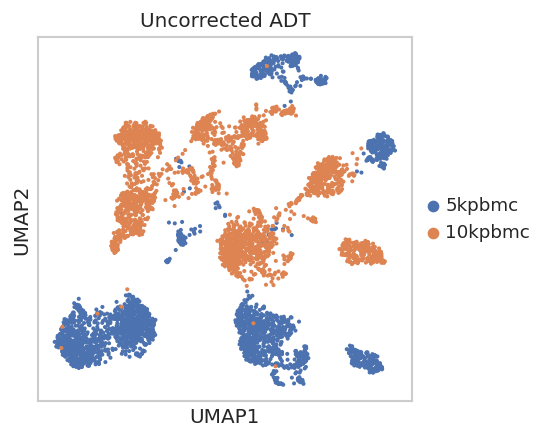

In [4]:
from sklearn.cluster import KMeans

N_PCS = min(15, adt.n_vars - 1, adt.n_obs - 1)
sc.pp.pca(adt, n_comps=N_PCS, random_state=SEED)
adt.obsm['X_pca_uncorrected'] = adt.obsm['X_pca'].copy()

if 'benchmark_label' not in adt.obs or adt.obs['benchmark_label'].nunique() < 2:
    n_proxy_labels = min(10, max(2, adt.n_obs // 250))
    proxy_labels = KMeans(n_clusters=n_proxy_labels, random_state=SEED, n_init='auto').fit_predict(
        adt.obsm['X_pca_uncorrected']
    )
    adt.obs['benchmark_label'] = pd.Categorical([f'adt_cluster_{i}' for i in proxy_labels])

sc.pp.neighbors(adt, use_rep='X_pca_uncorrected', random_state=SEED)
sc.tl.umap(adt, random_state=SEED)
adt.obsm['X_umap_uncorrected'] = adt.obsm['X_umap'].copy()

sc.pl.umap(adt, color='batch', title='Uncorrected ADT', show=False)
_display_figure()


## cyCombinePy ADT correction

The cyCombinePy path follows the cytometry workflow. A batch-wise normalized layer is used only for SOM clustering. ComBat then corrects the log-transformed ADT values in `adata.X` within each SOM cluster, and the corrected expression is stored in `adata.layers["cycombine_corrected"]`.


In [ ]:
CYCOMBINE_ADT_NORMALIZED = 'cycombine_adt_normalized'

adt.layers[CYCOMBINE_ADT_NORMALIZED] = adt.X.copy()  # ANALYSIS_OK[layer-choice] .X holds log1p(counts) as set by _prepare_adt_from_mdata
cycombinepy.normalize(
    adt,
    method='scale',
    batch_key='batch',
    layer=CYCOMBINE_ADT_NORMALIZED,
)
cycombinepy.create_som(
    adt,
    xdim=6,
    ydim=6,
    rlen=5,
    seed=SEED,
    layer=CYCOMBINE_ADT_NORMALIZED,
    label_key='cycombine_som',
)
cycombine_report = cycombinepy.correct_data(
    adt,
    label_key='cycombine_som',
    batch_key='batch',
    layer=None,
    out_layer=CORRECTED_LAYER,
    error_policy='report',
    confound_policy='skip',
    return_report=True,
)

adt.obsm['X_cycombinepy'] = np.asarray(adt.layers[CORRECTED_LAYER]).copy()
print('report status:', cycombine_report['status'])
print('SOM clusters:', adt.obs['cycombine_som'].nunique())
print('benchmark labels:', adt.obs['benchmark_label'].nunique())

## Harmony on ADT PCA

Harmony adjusts a low-dimensional representation rather than marker values. Harmony is therefore included only in the embedding benchmark. It is not included in expression-level EMD or MAD.


In [ ]:
try:
    import harmonypy

    harmony_result = harmonypy.run_harmony(
        adt.obsm['X_pca_uncorrected'],
        adt.obs,
        'batch',
        max_iter_harmony=20,
    )
    harmony_embedding = np.asarray(harmony_result.Z_corr)
    if harmony_embedding.shape[0] != adt.n_obs:
        harmony_embedding = harmony_embedding.T
    adt.obsm['X_harmony'] = harmony_embedding
    harmony_status = 'ok'
except Exception as exc:  # ANALYSIS_OK[optional-input] harmonypy is an optional benchmark dep; skipping is documented behavior
    harmony_status = f'skipped: {type(exc).__name__}'

print('Harmony:', harmony_status)

## totalVI latent space and denoised proteins

totalVI models RNA and protein jointly. The MuData setup follows the scvi-tools tutorial: RNA counts come from `mdata.mod["rna_subset"].layers["counts"]`, protein values come from `mdata.mod["prot"].X`, and batch labels come from `mdata.mod["rna_subset"].obs["batch"]`. The latent representation is used for embedding metrics. Denoised proteins are stored on the raw protein scale, so this notebook applies `log1p` before comparing them with the log-transformed ADT expression matrices.


In [ ]:
TOTALVI_DENOISED_LAYER = 'totalvi_denoised_protein'
TOTALVI_DENOISED_LOG1P_LAYER = 'totalvi_denoised_protein_log1p'
_totalvi_max_epochs_env = os.environ.get('TOTALVI_MAX_EPOCHS')
TOTALVI_MAX_EPOCHS = int(_totalvi_max_epochs_env) if _totalvi_max_epochs_env is not None else None
TOTALVI_N_SAMPLES = int(os.environ.get('TOTALVI_N_SAMPLES', '25'))

totalvi_training_summary = pd.DataFrame()
try:
    if mdata_subset is None:
        raise RuntimeError('MuData source unavailable')

    import scvi
    import torch

    scvi.settings.seed = SEED
    torch.set_float32_matmul_precision('high')
    mdata_totalvi = mdata_subset.copy()
    mdata_totalvi.mod["prot"].X = _as_dense(mdata_totalvi.mod["prot"].X)
    mdata_totalvi.mod["rna_subset"].X = _as_dense(mdata_totalvi.mod["rna_subset"].X)
    mdata_totalvi.mod["rna_subset"].layers['counts'] = _as_dense(
        mdata_totalvi.mod["rna_subset"].layers['counts']
    )

    scvi.model.TOTALVI.setup_mudata(
        mdata_totalvi,
        rna_layer='counts',
        protein_layer=None,
        batch_key='batch',
        modalities={
            'rna_layer': 'rna_subset',
            'protein_layer': 'prot',
            'batch_key': 'rna_subset',
        },
    )
    totalvi_model = scvi.model.TOTALVI(mdata_totalvi)
    totalvi_model.train(
        max_epochs=TOTALVI_MAX_EPOCHS,
        early_stopping=True,
        accelerator='cpu',
        devices=1,
        enable_progress_bar=False,
    )
    adt.obsm['X_totalVI'] = totalvi_model.get_latent_representation()
    _, protein_denoised = totalvi_model.get_normalized_expression(
        n_samples=TOTALVI_N_SAMPLES,
        return_mean=True,
    )
    if hasattr(protein_denoised, 'to_numpy'):
        protein_denoised = protein_denoised.to_numpy()
    protein_denoised = np.asarray(protein_denoised, dtype=float)
    adt.layers[TOTALVI_DENOISED_LAYER] = protein_denoised
    adt.layers[TOTALVI_DENOISED_LOG1P_LAYER] = np.log1p(np.clip(protein_denoised, 0, None))

    history = totalvi_model.history
    totalvi_training_summary = pd.DataFrame(
        [
            {
                'epochs_trained': len(history['elbo_train']) if 'elbo_train' in history else np.nan,
                'n_samples_normalized_expression': TOTALVI_N_SAMPLES,
                'elbo_train_last': float(np.ravel(history['elbo_train'].iloc[-1])[0])
                if 'elbo_train' in history
                else np.nan,
                'elbo_validation_last': float(np.ravel(history['elbo_validation'].iloc[-1])[0])
                if 'elbo_validation' in history
                else np.nan,
            }
        ]
    )
    totalvi_status = 'ok'
except Exception as exc:  # ANALYSIS_OK[optional-input] scvi and MuData are optional benchmark deps; skipping is documented behavior
    totalvi_status = f'skipped: {type(exc).__name__}'

print('totalVI:', totalvi_status)
totalvi_training_summary

## Benchmark metrics

The benchmark has two tables because the methods return different objects. Expression metrics use EMD and MAD across batches within the cyCombinePy SOM clusters and include only methods that produce ADT expression values. Embedding metrics use `scib_metrics`: iLISI on nearest-neighbor graphs and batch silhouette within the proxy label groups. Higher iLISI and higher rescaled batch silhouette indicate stronger batch mixing for the selected representation.


In [ ]:
def _summarize_expression(adata: ad.AnnData, method: str, layer: str | None) -> dict[str, float | str]:
    emd = cycombinepy.compute_emd(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    mad = cycombinepy.compute_mad(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    return {
        'method': method,
        'mean_emd': float(emd['emd'].mean()),
        'median_emd': float(emd['emd'].median()),
        'mean_mad': float(mad['mad'].mean()),
        'median_mad': float(mad['mad'].median()),
    }


def _scib_embedding_metrics(
    embedding: np.ndarray,
    batch: pd.Series,
    labels: pd.Series,
    n_neighbors: int = 30,
) -> dict[str, float | str]:
    from scib_metrics import ilisi_knn, silhouette_batch
    from scib_metrics.nearest_neighbors import pynndescent

    embedding = np.asarray(embedding, dtype=float)
    batch_codes = batch.astype('category').cat.codes.to_numpy()
    label_codes = labels.astype('category').cat.codes.to_numpy()
    if np.unique(batch_codes).size < 2 or embedding.shape[0] < 3:
        return {'scib_ilisi': float('nan'), 'scib_silhouette_batch': float('nan')}

    k = min(n_neighbors, embedding.shape[0] - 1)
    knn = pynndescent(embedding, n_neighbors=k, random_state=SEED, n_jobs=1)
    result = {'scib_ilisi': float(ilisi_knn(knn, batch_codes))}
    if np.unique(label_codes).size > 1:
        result['scib_silhouette_batch'] = float(
            silhouette_batch(embedding, label_codes, batch_codes)
        )
    else:
        result['scib_silhouette_batch'] = float('nan')
    return result


def _summarize_embedding(adata: ad.AnnData, method: str, rep_key: str) -> dict[str, float | str]:
    embedding = np.asarray(adata.obsm[rep_key])
    metrics = _scib_embedding_metrics(
        embedding,
        batch=adata.obs['batch'],
        labels=adata.obs['benchmark_label'],
    )
    return {'method': method, **metrics}


expression_sources: list[tuple[str, str | None]] = [
    ('uncorrected', None),
    ('cyCombinePy', CORRECTED_LAYER),
]
if TOTALVI_DENOISED_LOG1P_LAYER in adt.layers:
    expression_sources.append(('totalVI log1p denoised', TOTALVI_DENOISED_LOG1P_LAYER))

expression_table = pd.DataFrame(
    [_summarize_expression(adt, method, layer) for method, layer in expression_sources]
)

embedding_sources = {
    'uncorrected PCA': 'X_pca_uncorrected',
    'cyCombinePy': 'X_cycombinepy',
}
if 'X_harmony' in adt.obsm:
    embedding_sources['Harmony'] = 'X_harmony'
if 'X_totalVI' in adt.obsm:
    embedding_sources['totalVI'] = 'X_totalVI'

embedding_table = pd.DataFrame(
    [_summarize_embedding(adt, method, key) for method, key in embedding_sources.items()]
)

display(expression_table)
display(embedding_table)

## UMAP panels colored by batch

The UMAP panels are computed from each available representation. They are a qualitative check for batch mixing and should be read together with the embedding metrics, not as a replacement for them.


In [ ]:
def _umap_from_rep(adata: ad.AnnData, rep_key: str) -> np.ndarray:
    holder = ad.AnnData(X=np.zeros((adata.n_obs, 1)), obs=adata.obs.copy())
    holder.obsm[rep_key] = np.asarray(adata.obsm[rep_key])
    sc.pp.neighbors(holder, use_rep=rep_key, n_neighbors=15, random_state=SEED)
    sc.tl.umap(holder, random_state=SEED)
    return holder.obsm['X_umap']


umap_panels = []
for method, rep_key in embedding_sources.items():
    umap_panels.append((method, _umap_from_rep(adt, rep_key)))

batch_codes = adt.obs['batch'].astype('category').cat.codes.to_numpy()
palette = sns.color_palette('tab10', n_colors=adt.obs['batch'].nunique())
fig, axes = plt.subplots(1, len(umap_panels), figsize=(4 * len(umap_panels), 4), squeeze=False)
for ax, (method, coords) in zip(axes.ravel(), umap_panels):
    for code, batch_name in enumerate(adt.obs['batch'].astype('category').cat.categories):
        mask = batch_codes == code
        ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.55, label=batch_name, color=palette[code])
    ax.set_title(method)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
axes.ravel()[0].legend(title='batch', loc='best', markerscale=2)
fig.tight_layout()
_display_figure(fig)

## Interpreting the benchmark

- The expression table compares `uncorrected`, `cyCombinePy`, and `totalVI log1p denoised` on the same log scale.
- The embedding table compares `uncorrected PCA`, `cyCombinePy`, `Harmony`, and `totalVI` using the same scIB-style metrics.
- cyCombinePy uses the corrected ADT expression matrix directly as its embedding input (14 markers). Harmony requires a low-dimensional input so both uncorrected and Harmony embeddings start from PCA; this is an intentional asymmetry.
- Harmony is absent from the expression table because it does not produce corrected ADT expression values in this workflow.
- The batch-silhouette labels are proxy labels derived from uncorrected ADT PCA when curated cell labels are not available. This makes the score useful for checking local batch mixing, but it is not a biological conservation metric.
- These metrics describe batch mixing and ADT distribution alignment for this subset. They do not rank the methods for every downstream analysis.